In [1]:
import numpy as np
import matplotlib.pyplot as plt

perdidatotal=[]


#Definir la función sigmoide
def sigmoid(x):
  return 1/(1+np.exp(-x))


#Función de entrenamiento de la regresión logística
def logistic_regression(X,y,lr,epochs): #epochs -> El número de veces que entreno el modelo.

  m,n=X.shape
  theta=np.zeros(n)

  #Descenso del gradiente
  for epoch in range(epochs):
    #Calcular la probabilidad (predicción) y la perdida.
    z=np.dot(X,theta)
    h=sigmoid(z)
    loss=-np.mean(y*np.log(h)+(1-y)*np.log(1-h)) #Cálculo de la función de perdida.
    perdidatotal.append(loss)

    #Calcular el gradiente.
    gradient=np.dot(X.T,(h-y))/m

    #Actualizar parametros
    theta-=lr*gradient

    #Imprimir la perdidad de cada época
    if(epoch+1)%100==0:
      print(f"Epoca {epoch+1}/{epochs}, Perdida (Loss):{loss}")

  return theta


In [2]:
#Datos de ejemplo:
X = np.array([[1, 2], [1, 3], [1, 4], [1, 5]])
y = np.array([0, 0, 1, 1])

#Entrenar el modelo.
learning_rate=0.1
num_epochs=1000
optimal_params=logistic_regression(X,y,learning_rate,num_epochs)

Epoca 100/1000, Perdida (Loss):0.5297226475311346
Epoca 200/1000, Perdida (Loss):0.4411731344833296
Epoca 300/1000, Perdida (Loss):0.37969678169767873
Epoca 400/1000, Perdida (Loss):0.3351683765663329
Epoca 500/1000, Perdida (Loss):0.30160014920920913
Epoca 600/1000, Perdida (Loss):0.27540291236941555
Epoca 700/1000, Perdida (Loss):0.2543551007877653
Epoca 800/1000, Perdida (Loss):0.23703032782480188
Epoca 900/1000, Perdida (Loss):0.22247951428947998
Epoca 1000/1000, Perdida (Loss):0.2100501685444313


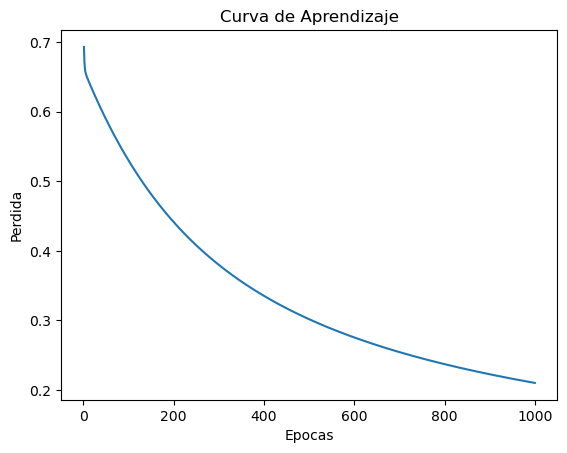

Parametros óptimos: [-5.97303274  1.7764563 ]


In [3]:
#Plotear la curva de aprendizaje.
plt.plot(range(1, num_epochs+1), perdidatotal)
plt.xlabel("Epocas")
plt.ylabel("Perdida")
plt.title("Curva de Aprendizaje")
plt.show()
print("Parametros óptimos:",optimal_params)

# Lo mismo pero implementando la libreria scikit-learn

In [4]:
from sklearn.linear_model import LogisticRegression

#Datos de ejemplo:
X = np.array([[1, 2], [1, 3], [1, 4], [1, 5]])
y = np.array([0, 0, 1, 1])

#Entrenar el modelo
modelo=LogisticRegression()
modelo.fit(X,y)

#Parametros encontrados
print("Parametros óptimos conseguidos:", modelo.intercept_, modelo.coef_)

Parametros óptimos conseguidos: [-3.35333948] [[1.15620192e-04 9.58114714e-01]]


In [37]:
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Dataset
X, y = make_moons(n_samples=200, noise=0.25, random_state=42)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Modelo
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)

# Probabilidades
y_prob = log_reg.predict_proba(X_test)[:, 1]


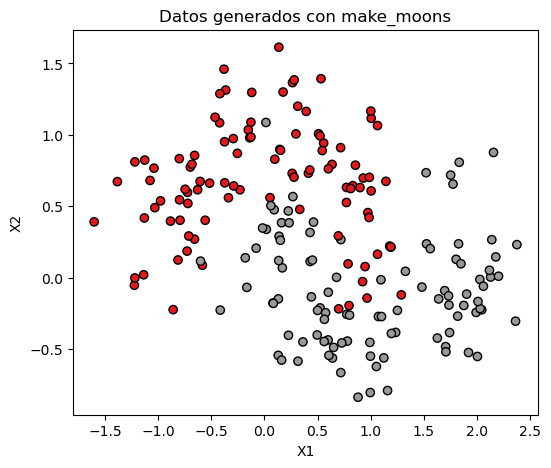

In [55]:
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Generar dataset
X, y = make_moons(n_samples=200, noise=0.25, random_state=42)

# Dividir train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Entrenar modelo
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)

# Probabilidades en test
y_prob = log_reg.predict_proba(X_test)[:, 1]

# Visualizar datos
plt.figure(figsize=(6,5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Set1, edgecolor="k")
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Datos generados con make_moons")
plt.show()


In [57]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

def metricas_completas(y_true, y_pred):
    TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()
    SNS = TP / (TP + FN) if (TP + FN) > 0 else 0
    SPC = TN / (TN + FP) if (TN + FP) > 0 else 0
    PRC = TP / (TP + FP) if (TP + FP) > 0 else 0
    NPV = TN / (TN + FN) if (TN + FN) > 0 else 0
    ACC = (TP + TN) / (TP + TN + FP + FN)
    F1  = 2 * PRC * SNS / (PRC + SNS) if (PRC + SNS) > 0 else 0
    GM  = (SNS * SPC) ** 0.5
    return SNS, SPC, PRC, NPV, ACC, F1, GM

# ✅ Forzar umbrales cada 0.02 de 0 a 1
thresholds = np.round(np.arange(0, 1.01, 0.02), 2)

# Calcular métricas para cada umbral
results = []
for thr in thresholds:
    y_pred_thr = (y_prob >= thr).astype(int)
    results.append(metricas_completas(y_test, y_pred_thr))

# DataFrame con umbrales exactos como índice
df_metrics = pd.DataFrame(
    results,
    columns=["SNS", "SPC", "PRC", "NPV", "ACC", "F1", "GM"],
    index=thresholds
)

df_metrics


,SNS,SPC,PRC,NPV,ACC,F1,GM
0.00,1.000000,0.00000,0.466667,0.000000,0.466667,0.636364,0.000000
0.02,1.000000,0.06250,0.482759,1.000000,0.500000,0.651163,0.250000
0.04,1.000000,0.21875,0.528302,1.000000,0.583333,0.691358,0.467707
0.06,0.964286,0.28125,0.540000,0.900000,0.600000,0.692308,0.520774
0.08,0.964286,0.34375,0.562500,0.916667,0.633333,0.710526,0.575737
0.10,0.964286,0.40625,0.586957,0.928571,0.666667,0.729730,0.625892
0.12,0.964286,0.56250,0.658537,0.947368,0.750000,0.782609,0.736485
0.14,0.964286,0.65625,0.710526,0.954545,0.800000,0.818182,0.795495
0.16,0.964286,0.65625,0.710526,0.954545,0.800000,0.818182,0.795495
0.18,0.964286,0.75000,0.771429,0.960000,0.850000,0.857143,0.850420


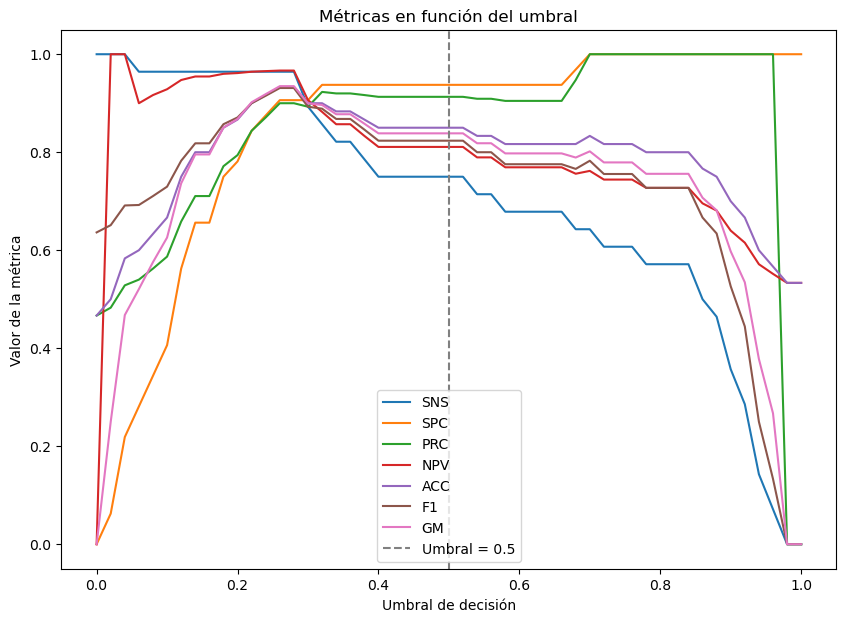

In [58]:
plt.figure(figsize=(10,7))
for col in df_metrics.columns:
    plt.plot(df_metrics.index, df_metrics[col], label=col)

plt.axvline(0.5, color="gray", linestyle="--", label="Umbral = 0.5")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor de la métrica")
plt.title("Métricas en función del umbral")
plt.legend()
plt.show()


In [60]:
# Mejor umbral según F1
best_thr = df_metrics["F1"].idxmax()
best_metrics = df_metrics.loc[best_thr]

# Acceso directo al umbral 0.50
thr_05 = 0.50  

comparison = pd.DataFrame(
    [df_metrics.loc[thr_05], df_metrics.loc[best_thr]],
    index=[f"Umbral {thr_05:.2f}", f"Mejor umbral ({best_thr:.2f})"]
)

print("Mejor umbral según F1:", best_thr)
print("\nComparación de métricas:")
print(comparison)


Mejor umbral según F1: 0.26

Comparación de métricas:
                          SNS      SPC       PRC       NPV       ACC  \
Umbral 0.50          0.750000  0.93750  0.913043  0.810811  0.850000   
Mejor umbral (0.26)  0.964286  0.90625  0.900000  0.966667  0.933333   

                           F1        GM  
Umbral 0.50          0.823529  0.838525  
Mejor umbral (0.26)  0.931034  0.934818  


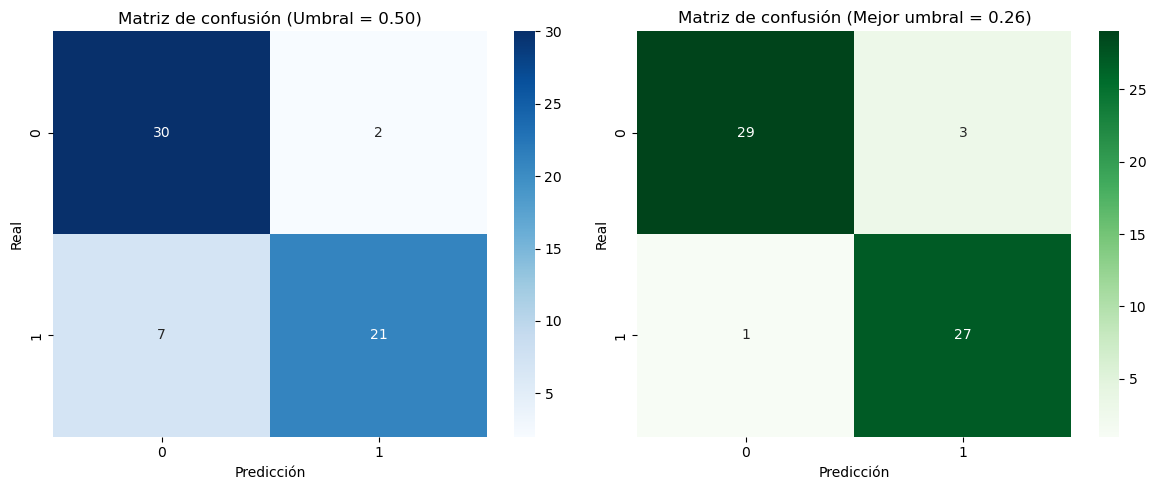

In [61]:
import seaborn as sns

from sklearn.metrics import confusion_matrix

y_pred_default = (y_prob >= thr_05).astype(int)
y_pred_best = (y_prob >= best_thr).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

cm_default = confusion_matrix(y_test, y_pred_default)
sns.heatmap(cm_default, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title(f"Matriz de confusión (Umbral = {thr_05:.2f})")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title(f"Matriz de confusión (Mejor umbral = {best_thr:.2f})")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()


Área bajo la curva (AUC): 0.950


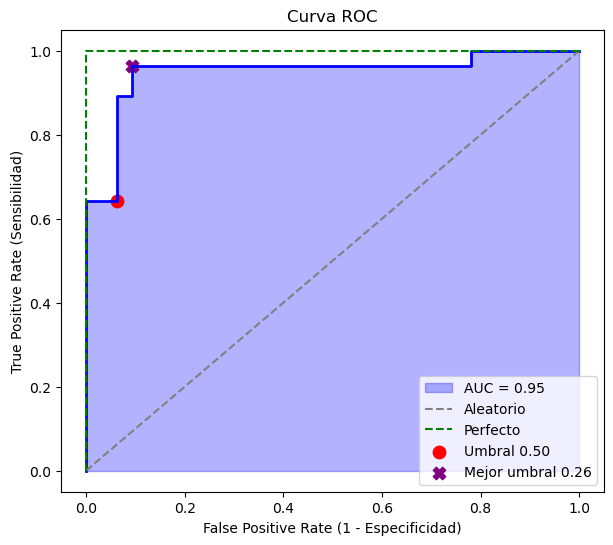

In [63]:
from sklearn.metrics import roc_curve, auc

# Calcular la curva ROC
fpr, tpr, roc_thr = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(f"Área bajo la curva (AUC): {roc_auc:.3f}")

plt.figure(figsize=(7,6))
plt.fill_between(fpr, tpr, alpha=0.3, color="blue", label=f"AUC = {roc_auc:.2f}")
plt.plot(fpr, tpr, color="blue", lw=2)

# Línea aleatoria
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Aleatorio")

# Curva ideal
plt.plot([0, 0, 1], [0, 1, 1], color="green", linestyle="--", label="Perfecto")

# ✅ Marcar punto en 0.50
thr_05 = 0.50
idx_05 = np.argmin(np.abs(roc_thr - thr_05))
plt.scatter(fpr[idx_05], tpr[idx_05], color="red", s=80, marker="o", label=f"Umbral {thr_05:.2f}")

# ✅ Marcar punto en mejor umbral
idx_best = np.argmin(np.abs(roc_thr - best_thr))
plt.scatter(fpr[idx_best], tpr[idx_best], color="purple", s=80, marker="X", label=f"Mejor umbral {best_thr:.2f}")

plt.xlabel("False Positive Rate (1 - Especificidad)")
plt.ylabel("True Positive Rate (Sensibilidad)")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()


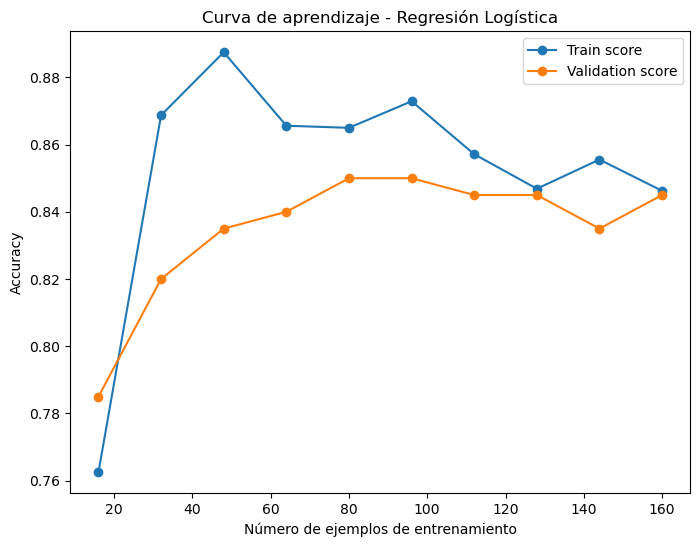

In [62]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(max_iter=200),
    X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, "o-", label="Train score")
plt.plot(train_sizes, test_mean, "o-", label="Validation score")
plt.xlabel("Número de ejemplos de entrenamiento")
plt.ylabel("Accuracy")
plt.title("Curva de aprendizaje - Regresión Logística")
plt.legend()
plt.show()


C:\Users\Usuario\AppData\Local\Temp\ipykernel_6640\3596435475.py:21: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, probs, levels=[0.5], colors="red", linestyles="--", linewidths=2,
C:\Users\Usuario\AppData\Local\Temp\ipykernel_6640\3596435475.py:25: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, probs, levels=[best_thr], colors="blue", linestyles="-.", linewidths=2,


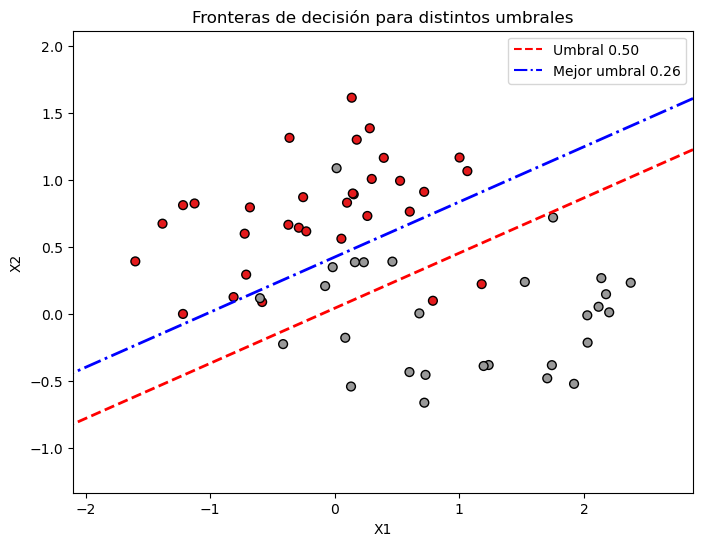

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Crear malla en el plano de características
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 200),
    np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]

# Probabilidades en la malla
probs = log_reg.predict_proba(grid)[:, 1].reshape(xx.shape)

# Gráfico
plt.figure(figsize=(8,6))

# Datos reales
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap=plt.cm.Set1, edgecolor="k", s=40)

# Frontera de decisión estándar (umbral 0.50)
plt.contour(xx, yy, probs, levels=[0.5], colors="red", linestyles="--", linewidths=2, 
            label="Umbral 0.50")

# Frontera de decisión con mejor umbral
plt.contour(xx, yy, probs, levels=[best_thr], colors="blue", linestyles="-.", linewidths=2, 
            label=f"Mejor umbral {best_thr:.2f}")

# Etiquetas y leyenda
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Fronteras de decisión para distintos umbrales")
red_line = plt.Line2D([], [], color="red", linestyle="--", label="Umbral 0.50")
blue_line = plt.Line2D([], [], color="blue", linestyle="-.", label=f"Mejor umbral {best_thr:.2f}")
plt.legend(handles=[red_line, blue_line])

plt.show()


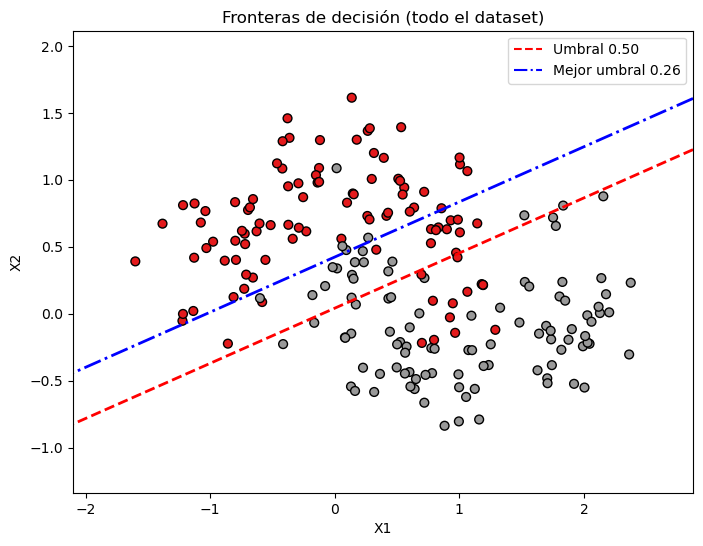

In [65]:
# Crear malla en el plano de características
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300),
    np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]

# Probabilidades en la malla
probs = log_reg.predict_proba(grid)[:, 1].reshape(xx.shape)

# Gráfico
plt.figure(figsize=(8,6))

# Puntos de TODO el dataset
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.Set1, edgecolor="k", s=40)

# Frontera de decisión estándar (umbral 0.50)
plt.contour(xx, yy, probs, levels=[0.5], colors="red", linestyles="--", linewidths=2)

# Frontera de decisión con mejor umbral
plt.contour(xx, yy, probs, levels=[best_thr], colors="blue", linestyles="-.", linewidths=2)

# Etiquetas y leyenda
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Fronteras de decisión (todo el dataset)")
red_line = plt.Line2D([], [], color="red", linestyle="--", label="Umbral 0.50")
blue_line = plt.Line2D([], [], color="blue", linestyle="-.", label=f"Mejor umbral {best_thr:.2f}")
plt.legend(handles=[red_line, blue_line])

plt.show()
